# 🌍 **Global Life Expectancy Analysis**

## 🎯 Aim

To analyze global life expectancy data using Python in order to identify major health and demographic factors affecting lifespan through data preprocessing, exploratory data analysis, and visualization techniques.

**OBJECTIVES:**

To clean and preprocess the dataset.

To identify and handle missing values.

To perform exploratory data analysis.

To visualize life expectancy trends across countries and genders.

To detect outliers and inconsistencies in the data.

To generate meaningful insights using Python.

**INTRODUCTION:**

Life expectancy is one of the most important indicators of a country’s overall health and development. By analyzing life expectancy data, meaningful insights can be obtained regarding healthcare quality, socio-economic conditions, and population wellbeing.

**DESCRIPTION**

The dataset contains global life expectancy records collected from the World Health Organization. It includes country-wise and gender-wise life expectancy values across multiple years.

# 📊**Column Descriptions**
 | Column Name              | Meaning                                                                                |
| ------------------------ | -------------------------------------------------------------------------------------- |
| `IND_ID`                 | Unique identifier for the health indicator record.                                     |
| `IND_CODE`               | Indicator code assigned by the World Health Organization for a specific health metric. |
| `IND_UUID`               | Unique universal identifier for the indicator dataset.                                 |
| `IND_PER_CODE`           | Indicator periodicity/code related to the measurement category.                        |
| `DIM_TIME`               | Year of the recorded data (e.g., 2000, 2001, etc.).                                    |
| `DIM_TIME_TYPE`          | Type of time measurement. In your dataset it is mostly `YEAR`.                         |
| `DIM_GEO_CODE_M49`       | Geographic country code based on the UN M49 standard.                                  |
| `DIM_GEO_CODE_TYPE`      | Type of geographic region (e.g., COUNTRY).                                             |
| `DIM_PUBLISH_STATE_CODE` | Publication status of the data (e.g., PUBLISHED).                                      |
| `IND_NAME`               | Name of the indicator being measured. Example: *Life expectancy (at birth)*.           |
| `GEO_NAME_SHORT`         | Short name of the country or geographic region.                                        |
| `DIM_SEX`                | Gender category for the data (`MALE`, `FEMALE`, or `BOTH`).                            |
| `AMOUNT_N`               | Main numerical value of life expectancy. This is the actual life expectancy value.     |
| `AMOUNT_NL`              | Lower confidence interval / lower estimated bound of the life expectancy value.        |
| `AMOUNT_NU`              | Upper confidence interval / upper estimated bound of the life expectancy value.        |



#📚 **Import Python Libraries**

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  📊**Load Dataset**

In [448]:
# Load the life expectancy dataset

df = pd.read_csv("/content/Global Life Expectancy Analysis.csv")

df.head()

,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,DIM_SEX,AMOUNT_N,AMOUNT_NL,AMOUNT_NU
0,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,688,COUNTRY,PUBLISHED,Life expectancy (at birth),Serbia,FEMALE,74.334559,74.254810,74.526428
1,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,690,COUNTRY,PUBLISHED,Life expectancy (at birth),Seychelles,FEMALE,76.455919,76.227948,76.712025
2,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,694,COUNTRY,PUBLISHED,Life expectancy (at birth),Sierra Leone,FEMALE,51.577824,50.603903,52.778978
3,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,702,COUNTRY,PUBLISHED,Life expectancy (at birth),Singapore,FEMALE,80.774170,80.751426,80.876353
4,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2000,YEAR,703,COUNTRY,PUBLISHED,Life expectancy (at birth),Slovakia,FEMALE,77.405510,77.356596,77.519091


# 🔍**Understand the Dataset**

Dataset understanding is the initial step in data analysis where we explore the dataset's columns, data types, number of records, and overall structure to gain familiarity with the data.

1. Check shape

In [ ]:
df.shape

(12936, 15)

2. Check column names

In [ ]:
df.columns

Index(['IND_ID', 'IND_CODE', 'IND_UUID', 'IND_PER_CODE', 'DIM_TIME',
       'DIM_TIME_TYPE', 'DIM_GEO_CODE_M49', 'DIM_GEO_CODE_TYPE',
       'DIM_PUBLISH_STATE_CODE', 'IND_NAME', 'GEO_NAME_SHORT', 'DIM_SEX',
       'AMOUNT_N', 'AMOUNT_NL', 'AMOUNT_NU'],
      dtype='object')

3. Check data types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12936 entries, 0 to 12935
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   IND_ID                  12936 non-null  object 
 1   IND_CODE                12936 non-null  object 
 2   IND_UUID                12936 non-null  object 
 3   IND_PER_CODE            12936 non-null  object 
 4   DIM_TIME                12936 non-null  int64  
 5   DIM_TIME_TYPE           12936 non-null  object 
 6   DIM_GEO_CODE_M49        12936 non-null  int64  
 7   DIM_GEO_CODE_TYPE       12936 non-null  object 
 8   DIM_PUBLISH_STATE_CODE  12936 non-null  object 
 9   IND_NAME                12936 non-null  object 
 10  GEO_NAME_SHORT          12936 non-null  object 
 11  DIM_SEX                 12936 non-null  object 
 12  AMOUNT_N                12896 non-null  float64
 13  AMOUNT_NL               12916 non-null  float64
 14  AMOUNT_NU               12916 non-null

# 🧹**Data Cleaning & Pre-processing**

Data cleaning and pre-processing is the process of improving data quality by handling missing values, removing duplicates, correcting inconsistencies, and transforming data into a suitable format for analysis.

🗑️ 1. Columns You Can Drop

Irrelevant identifier columns were removed during preprocessing to improve analysis efficiency

In [ ]:
df = df.drop(columns=['IND_ID', 'IND_CODE', 'IND_UUID','IND_PER_CODE','DIM_TIME_TYPE',
                      'DIM_PUBLISH_STATE_CODE','IND_NAME','AMOUNT_NL','AMOUNT_NU'])

print(df.head())

   DIM_TIME  DIM_GEO_CODE_M49 DIM_GEO_CODE_TYPE GEO_NAME_SHORT DIM_SEX  \
0      2000               688           COUNTRY         Serbia  FEMALE   
1      2000               690           COUNTRY     Seychelles  FEMALE   
2      2000               694           COUNTRY   Sierra Leone  FEMALE   
3      2000               702           COUNTRY      Singapore  FEMALE   
4      2000               703           COUNTRY       Slovakia  FEMALE   

    AMOUNT_N  
0  74.334559  
1  76.455919  
2  51.577824  
3  80.774170  
4  77.405510  


✂️ 2. Irrelevant Category you can drop in a column

In [ ]:
print('Unique values in DIM_SEX column:')
print(df['DIM_SEX'].unique())

Unique values in DIM_SEX column:
['FEMALE' 'MALE' 'TOTAL']


As the 'TOTAL' category in the DIM_SEX column is irrelevant, we can remove it out.

In [ ]:
category_to_remove = 'TOTAL'

df_filtered = df[df['DIM_SEX'] != category_to_remove]

print(f"DataFrame after removing '{category_to_remove}' from DIM_SEX:")
display(df_filtered.head())
print('\nUnique values in DIM_SEX after filtering:')
print(df_filtered['DIM_SEX'].unique())

DataFrame after removing 'TOTAL' from DIM_SEX:


,DIM_TIME,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,GEO_NAME_SHORT,DIM_SEX,AMOUNT_N
0,2000,688,COUNTRY,Serbia,FEMALE,74.334559
1,2000,690,COUNTRY,Seychelles,FEMALE,76.455919
2,2000,694,COUNTRY,Sierra Leone,FEMALE,51.577824
3,2000,702,COUNTRY,Singapore,FEMALE,80.774170
4,2000,703,COUNTRY,Slovakia,FEMALE,77.405510



Unique values in DIM_SEX after filtering:
['FEMALE' 'MALE']


🔍 3. Check null values

In [ ]:
df.isnull().sum()

,0
DIM_TIME,0
DIM_GEO_CODE_M49,0
DIM_GEO_CODE_TYPE,0
GEO_NAME_SHORT,0
DIM_SEX,0
AMOUNT_N,40


🔍 4. Fill Missing Values Using Mean:

Missing values in the confidence interval columns were identified and replaced using mean imputation to maintain dataset consistency.

In [ ]:
df['AMOUNT_N'] = df['AMOUNT_N'].fillna(df['AMOUNT_N'].mean())

🔍 5. Verify Missing Values Removed

In [ ]:
df.isnull().sum()

,0
DIM_TIME,0
DIM_GEO_CODE_M49,0
DIM_GEO_CODE_TYPE,0
GEO_NAME_SHORT,0
DIM_SEX,0
AMOUNT_N,0


🗑️ 6. Handling Duplicate Values:

Check Duplicate Rows- Duplicate rows were checked and removed to avoid redundancy and ensure data accuracy.

In [ ]:
df.duplicated().sum()

np.int64(0)

# **📝Formatting & Data Type Corrections**

Data formatting techniques such as string cleaning, whitespace removal, and datatype conversion were applied for consistency.

1. Check Data Types

In [ ]:
df.dtypes

,0
DIM_TIME,int64
DIM_GEO_CODE_M49,int64
DIM_GEO_CODE_TYPE,object
GEO_NAME_SHORT,object
DIM_SEX,object
AMOUNT_N,float64


2. Convert Country Names to Proper Format

In [ ]:
df['GEO_NAME_SHORT'] = df['GEO_NAME_SHORT'].str.title()

3. Remove Extra Spaces

In [ ]:
df['GEO_NAME_SHORT'] = df['GEO_NAME_SHORT'].str.strip()

# **⚙️Feature Engineering / Derived Features**

Feature engineering is the process of creating new variables (features) from existing data to improve analysis and extract more meaningful information.

Create Life Expectancy Category:

In [ ]:
def category(x):
    if x < 60:
        return 'Low'
    elif x < 75:
        return 'Medium'
    else:
        return 'High'

df['LIFE_EXPECTANCY_CATEGORY'] = df['AMOUNT_N'].apply(category)

Feature engineering was performed by creating a new categorical feature called LIFE_EXPECTANCY_CATEGORY from the existing numerical life expectancy column (AMOUNT_N).
The life expectancy values were grouped into three categories:

Low : Life Expectancy less than 60 years

Medium : Life Expectancy between 60 and 75 years

High : Life Expectancy greater than or equal to 75 years

This derived feature simplifies the interpretation of life expectancy data and enables easier comparison of countries based on their overall life expectancy levels.

# **🚨Outlier Detection**

Outliers are data points that differ significantly from the majority of observations in a dataset. They may indicate unusual conditions, measurement errors, or rare events.

**Calculate IQR and Detect Outliers**

In [ ]:
Q1 = df_filtered['AMOUNT_N'].quantile(0.25)
Q3 = df_filtered['AMOUNT_N'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df_filtered[(df_filtered['AMOUNT_N'] < lower_bound) | (df_filtered['AMOUNT_N'] > upper_bound)]

print("Number of Outliers:", len(outliers))

Q1: 64.267259875
Q3: 77.24137296500001
IQR: 12.974113090000017
Lower Bound: 44.80609023999997
Upper Bound: 96.70254260000004
Number of Outliers: 39


Outliers were identified using both the Interquartile Range (IQR) method and boxplot visualization.

The IQR was calculated as:

IQR=Q3−Q1

where:

Q1 = 25th percentile
Q3 = 75th percentile

The lower and upper bounds were determined using:

Lower Bound=Q1−1.5×IQR
Upper Bound=Q3+1.5×IQR

Any life expectancy value outside these bounds was considered an outlier.

**View the Outlier Records**

In [ ]:
outliers[['GEO_NAME_SHORT', 'DIM_TIME', 'DIM_SEX', 'AMOUNT_N']].head(10)

,GEO_NAME_SHORT,DIM_TIME,DIM_SEX,AMOUNT_N
285,Lesotho,2005,FEMALE,44.041179
334,Malawi,2000,FEMALE,45.346721
476,Lesotho,2006,FEMALE,43.538907
575,Eswatini,2002,FEMALE,45.072766
771,Eswatini,2003,FEMALE,43.832245
964,Eswatini,2004,FEMALE,42.946079
1175,Zambia,2000,FEMALE,45.138348
1307,Eswatini,2005,FEMALE,42.739857
1327,Eswatini,2006,FEMALE,43.784754
1407,Haiti,2010,FEMALE,36.599153


**Outlier Analysis Using Boxplot**

A boxplot was created to compare life expectancy across different gender categories (Male, Female, and Both).

The plot helps visualize the spread of data, median values, and potential outliers within each group.

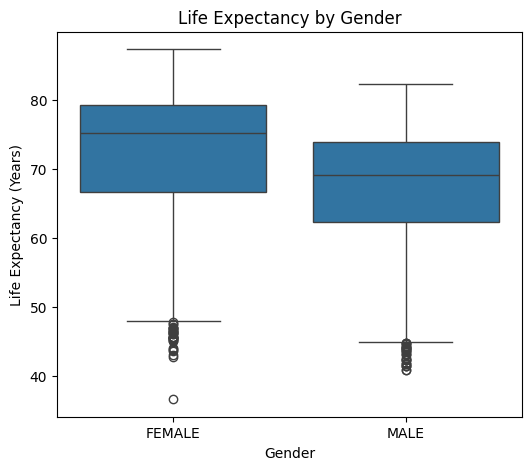

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x='DIM_SEX', y='AMOUNT_N', data=df_filtered)

plt.title('Life Expectancy by Gender')
plt.xlabel('Gender')
plt.ylabel('Life Expectancy (Years)')

plt.show()

**Explanation:**

The individual points appearing outside the whiskers of the boxplot represent outliers, which are life expectancy values significantly lower or higher than the majority of observations for that gender category.

In this dataset, most outliers correspond to countries experiencing unusually low life expectancy due to factors such as poor healthcare access, disease burden, economic challenges, or social instability.

These outliers were retained in the analysis because they represent actual country-level observations rather than data entry errors and provide valuable insights into global health disparities.

# 📁**Final Cleaned Dataset Check**

The purpose is to verify that all preprocessing steps were successfully completed and that the dataset is ready for analysis.

In [ ]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8624 entries, 0 to 8623
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   DIM_TIME           8624 non-null   int64  
 1   DIM_GEO_CODE_M49   8624 non-null   int64  
 2   DIM_GEO_CODE_TYPE  8624 non-null   object 
 3   GEO_NAME_SHORT     8624 non-null   object 
 4   DIM_SEX            8624 non-null   object 
 5   AMOUNT_N           8584 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 471.6+ KB


| Column                | What it Specifies                                                                                     |
| --------------------- | ----------------------------------------------------------------------------------------------------- |
| **DIM_TIME**          | The year in which the life expectancy was recorded. Example: 2000, 2001, 2002.                        |
| **DIM_GEO_CODE_M49**  | Numeric country/region code based on the United Nations M49 standard. Each country has a unique code. |
| **DIM_GEO_CODE_TYPE** | The type of geographic code used (e.g., M49 country code classification).                             |
| **GEO_NAME_SHORT**    | The name of the country or region. Example: India, Japan, Afghanistan.                                |
| **DIM_SEX**           | Gender category for the observation. Values are typically FEMALE, MALE, or BOTH.                      |
| **AMOUNT_N**          | Life expectancy value (in years). This is the main variable being analyzed.                           |


In [ ]:
df_filtered.head()

,DIM_TIME,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,GEO_NAME_SHORT,DIM_SEX,AMOUNT_N
0,2000,688,COUNTRY,Serbia,FEMALE,74.334559
1,2000,690,COUNTRY,Seychelles,FEMALE,76.455919
2,2000,694,COUNTRY,Sierra Leone,FEMALE,51.577824
3,2000,702,COUNTRY,Singapore,FEMALE,80.774170
4,2000,703,COUNTRY,Slovakia,FEMALE,77.405510


After completing the data cleaning and preprocessing steps, a final inspection of the dataset was performed using df.info() and df.head().

1. df.info() was used to verify the data types of all columns, confirm that
missing values had been handled, and ensure the dataset structure was correct.
2. df.head() was used to preview the first few records and validate that the cleaned and transformed data appeared as expected.

# **📈EDA (Exploratory Data Analysis)**

EDA is the process of exploring and understanding your data before drawing conclusions or building models.

EDA includes both visual and non-visual analysis. Non-visual EDA involves examining dataset structure, data types, descriptive statistics, missing values, duplicates, unique values, correlations, and group-wise summaries. Visualization is used later to communicate these findings more effectively.

**NON-VISUAL EDA**

Question. 1

What are the key statistics of numerical variables?

In [ ]:
df_filtered.describe()

,DIM_TIME,DIM_GEO_CODE_M49,AMOUNT_N
count,8624.000000,8624.000000,8584.000000
mean,2010.500000,453.709184,70.188829
std,6.344657,273.239254,8.920845
min,2000.000000,1.000000,36.599153
25%,2005.000000,217.000000,64.267260
50%,2010.500000,437.000000,71.490219
75%,2016.000000,691.000000,77.241373
max,2021.000000,958.000000,87.371027


**Insight**

Provides count, mean, standard deviation, minimum, quartiles, and maximum values. Gives an overall understanding of the distribution of life expectancy.

Question. 2

How many unique countries are present?

In [ ]:
df_filtered['GEO_NAME_SHORT'].nunique()

196

**Insight**

Returns the number of unique countries. Shows the geographical coverage of the dataset.

Question. 3

How are observations distributed among Low, Medium, and High categories?

In [ ]:
df_filtered['LIFE_EXPECTANCY_CATEGORY'].value_counts()

,count
LIFE_EXPECTANCY_CATEGORY,
Medium,4213
High,3141
Low,1270


**Insight**

Displays category frequencies. Identifies the dominant life expectancy group.

Question. 4

Which country has the highest average life expectancy?

In [ ]:
df_filtered.groupby('GEO_NAME_SHORT')['AMOUNT_N'].mean().sort_values(ascending=False).head(10)

,AMOUNT_N
GEO_NAME_SHORT,
Japan,83.140515
Switzerland,81.901748
Australia,81.810121
Singapore,81.665177
Iceland,81.518005
Italy,81.414860
Spain,81.336883
Sweden,81.187504
France,80.974840


**Insight**

Lists the top 10 countries. Highlights countries with the best life expectancy outcomes.

Question. 5

Which countries have the lowest average life expectancy?

In [ ]:
df_filtered.groupby('GEO_NAME_SHORT')['AMOUNT_N'].mean().sort_values().head(10)

,AMOUNT_N
GEO_NAME_SHORT,
Lesotho,48.146140
Eswatini,48.185473
Central African Republic,48.912589
Somalia,51.339877
Zimbabwe,52.073454
Mozambique,54.246369
Guinea-Bissau,55.195030
Sierra Leone,55.313178
Zambia,55.410346


**Insight**

Lists the bottom 10 countries. Highlights countries facing major health challenges.

Question. 6

Does life expectancy vary by gender?

In [ ]:
df_filtered.groupby('DIM_SEX')['AMOUNT_N'].mean()

,AMOUNT_N
DIM_SEX,
FEMALE,72.604214
MALE,67.771191


**Insight**

Shows average life expectancy for each gender. Females generally have higher life expectancy than males.

Question. 7

How has average life expectancy changed over time?

In [ ]:
df_filtered.groupby('DIM_TIME')['AMOUNT_N'].mean()

,AMOUNT_N
DIM_TIME,
2000,67.025031
2001,67.359550
2002,67.533179
2003,67.831459
2004,68.198417
2005,68.525202
2006,68.904996
2007,69.368401
2008,69.645114


**Insight**

Provides yearly averages. Reveals whether life expectancy is improving over time.

Question. 8

How does average life expectancy differ across categories?

In [ ]:
df_filtered.groupby('LIFE_EXPECTANCY_CATEGORY')['AMOUNT_N'].mean()

,AMOUNT_N
LIFE_EXPECTANCY_CATEGORY,
High,79.053215
Low,54.675425
Medium,68.340635


**Insight**

Shows average life expectancy for Low, Medium, and High groups. Validates the effectiveness of the derived feature.

# 📈**Structure of EDA with Visualisations**

# 1️⃣ **UNIVARIATE ANALYSIS**

Analysis of one variable at a time.

Purpose:

-Understand distribution

-Identify outliers

-Check frequency and spread



Question. 1

What is the distribution of life expectancy values?

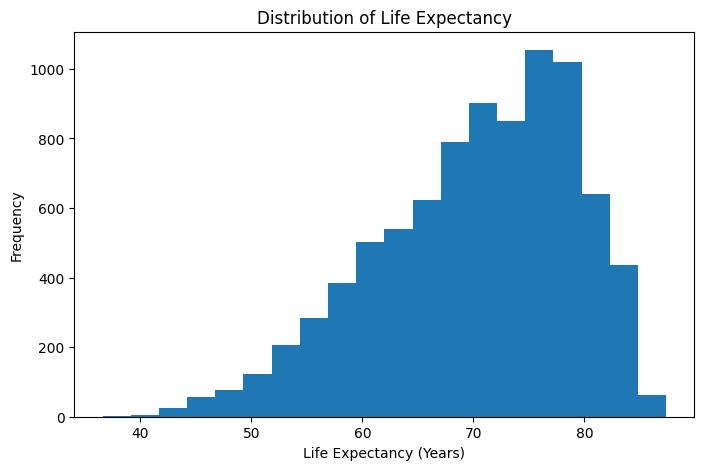

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df_filtered['AMOUNT_N'], bins=20)

plt.title('Distribution of Life Expectancy')
plt.xlabel('Life Expectancy (Years)')
plt.ylabel('Frequency')

plt.show()

**Insight**

Most life expectancy values are concentrated between 60 and 80 years. The majority of countries have moderate to high life expectancy.

Question. 2

What is the density distribution of life expectancy?

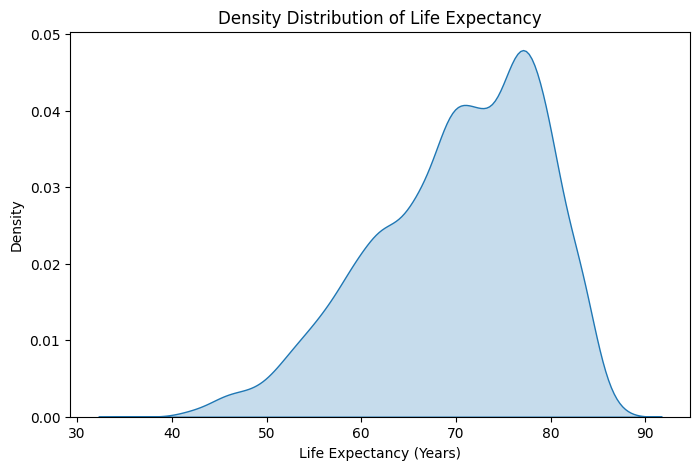

In [ ]:
plt.figure(figsize=(8,5))

sns.kdeplot(df_filtered['AMOUNT_N'], fill=True)

plt.title('Density Distribution of Life Expectancy')
plt.xlabel('Life Expectancy (Years)')

plt.show()

**Insight**

The density curve shows where life expectancy values are most concentrated. Helps identify the most common life expectancy range globally.

Question. 3

Are there any outliers in life expectancy?

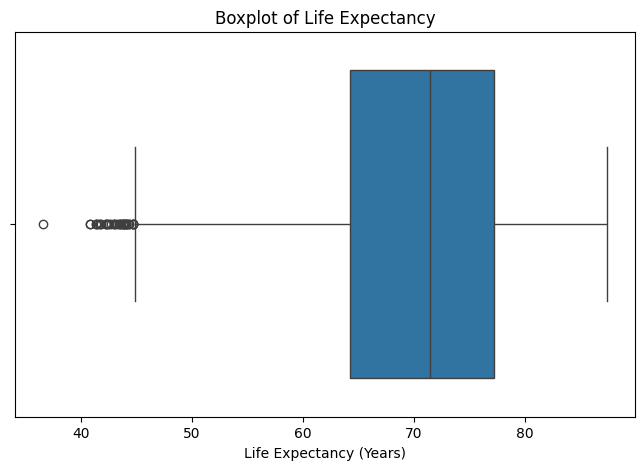

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df_filtered['AMOUNT_N'])

plt.title('Boxplot of Life Expectancy')
plt.xlabel('Life Expectancy (Years)')

plt.show()

**Insight**

Several observations appear outside the whiskers and are considered outliers. These outliers represent countries with unusually low life expectancy values.

Question. 4

How are records distributed across genders?

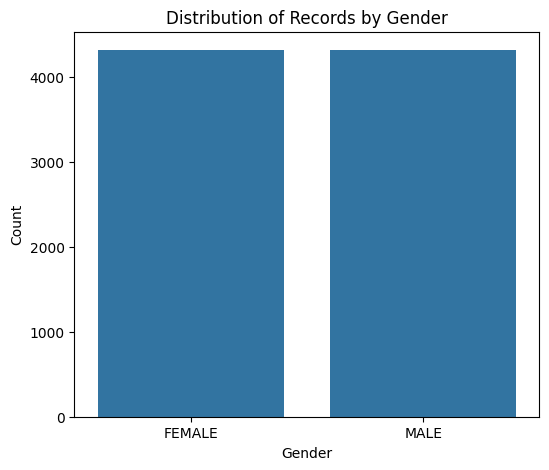

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(x='DIM_SEX', data=df_filtered)

plt.title('Distribution of Records by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.show()

**Insight**

Records are distributed among Male, Female, and Both categories.
The dataset supports gender-wise comparisons.

Question. 5

How are observations distributed across life expectancy categories?

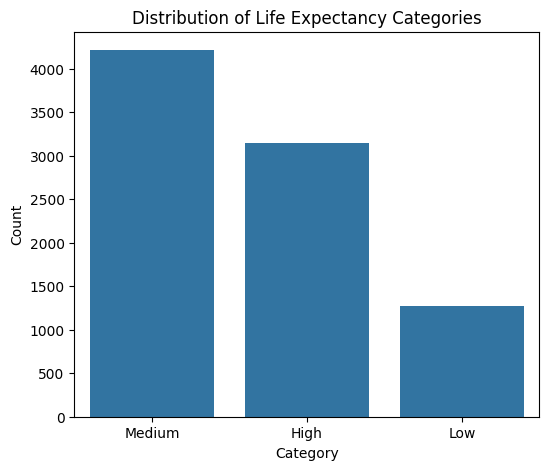

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(x='LIFE_EXPECTANCY_CATEGORY', data=df_filtered)

plt.title('Distribution of Life Expectancy Categories')
plt.xlabel('Category')
plt.ylabel('Count')

plt.show()

**Insight**

Most observations belong to Medium and High categories. Many countries have achieved relatively high life expectancy levels.

Question. 6

How are records distributed across geographic code types?

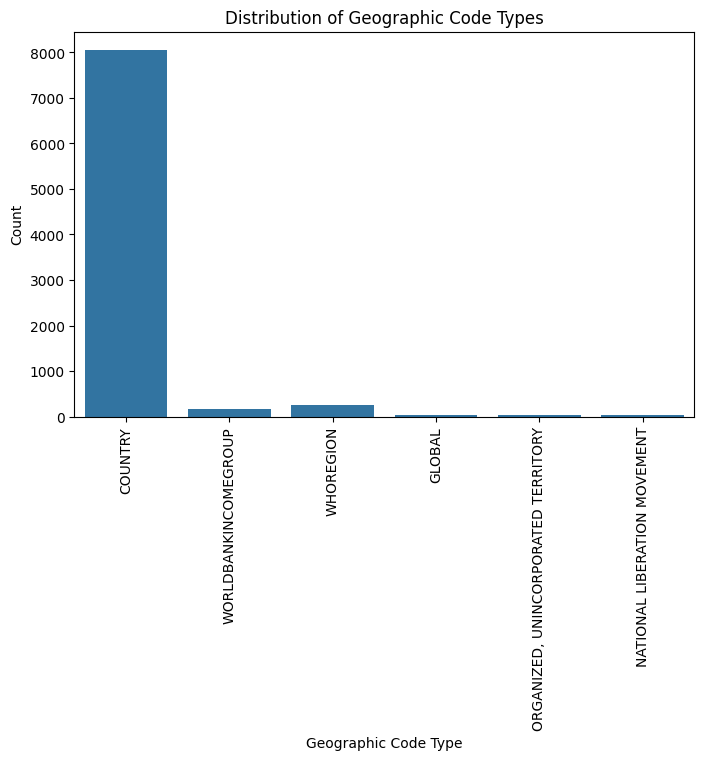

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='DIM_GEO_CODE_TYPE',
    data=df_filtered
)

plt.title('Distribution of Geographic Code Types')
plt.xlabel('Geographic Code Type')
plt.ylabel('Count')

plt.xticks(rotation=90)

plt.show()

**Insight**

Shows which geographic code type appears most frequently.

# **2️⃣**. **BIVARIATE ANALYSIS**

Analysis of two variables together.

Purpose:

-Compare groups

-Identify trends and relationships

Question. 7

Does life expectancy vary across geographic code types?

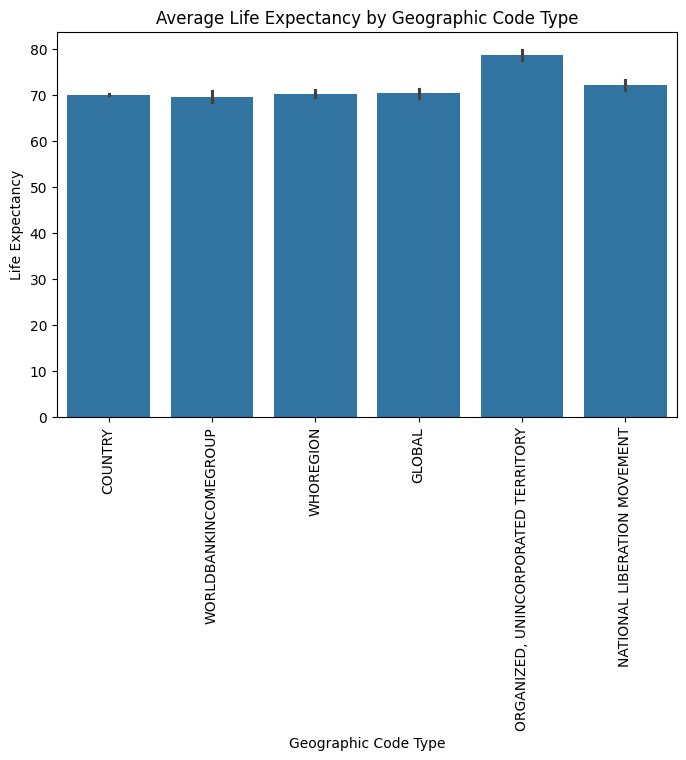

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='DIM_GEO_CODE_TYPE',
    y='AMOUNT_N',
    data=df_filtered
)

plt.title('Average Life Expectancy by Geographic Code Type')
plt.xlabel('Geographic Code Type')
plt.ylabel('Life Expectancy')

plt.xticks(rotation=90)

plt.show()

**Insight**

Shows whether different geographic code types have different average life expectancy values.

Question. 8

Does life expectancy vary by gender?

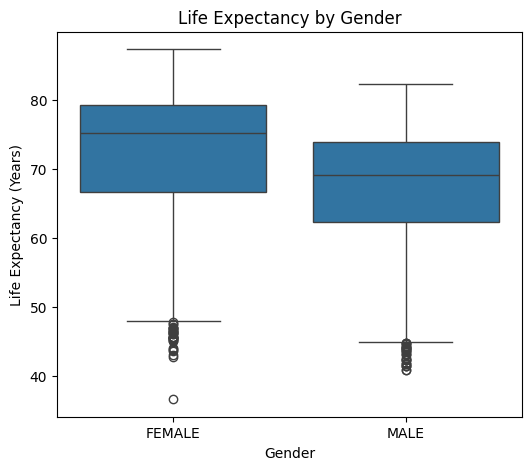

In [ ]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x='DIM_SEX',
    y='AMOUNT_N',
    data=df_filtered
)

plt.title('Life Expectancy by Gender')
plt.xlabel('Gender')
plt.ylabel('Life Expectancy (Years)')

plt.show()

**Insight**

Female life expectancy is generally higher than male life expectancy. Women tend to live longer than men globally.

Question. 9

What is the average life expectancy for each gender?

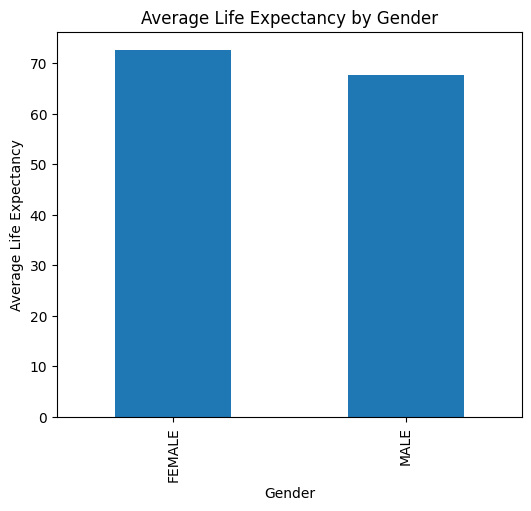

In [ ]:
gender_avg = df_filtered.groupby('DIM_SEX')['AMOUNT_N'].mean()

plt.figure(figsize=(6,5))

gender_avg.plot(kind='bar')

plt.title('Average Life Expectancy by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Life Expectancy')

plt.show()

**Insight**

Female life expectancy has a higher average value. A gender gap exists in life expectancy outcomes.

Question. 10

How has life expectancy changed over time?

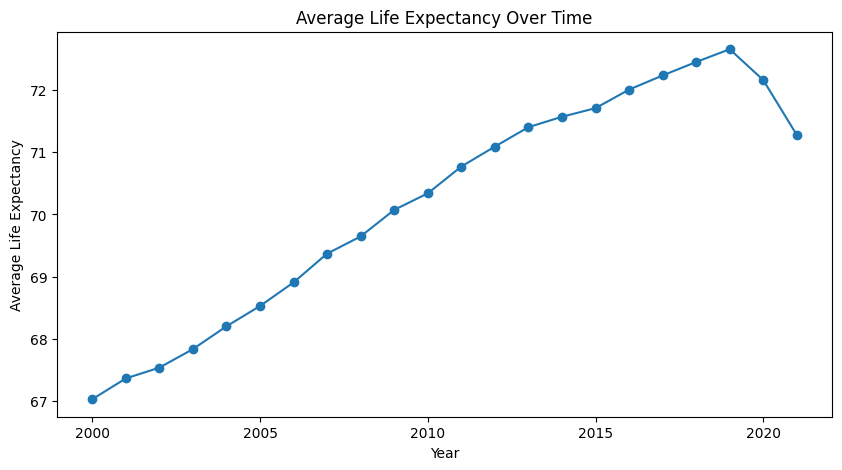

In [ ]:
yearly_avg = df_filtered.groupby('DIM_TIME')['AMOUNT_N'].mean()

plt.figure(figsize=(10,5))

plt.plot(
    yearly_avg.index,
    yearly_avg.values,
    marker='o'
)

plt.title('Average Life Expectancy Over Time')
plt.xlabel('Year')
plt.ylabel('Average Life Expectancy')

plt.show()

**Insight**

Life expectancy generally increases over time. Healthcare and living conditions have improved globally.

Question. 11

Which countries have the highest life expectancy?

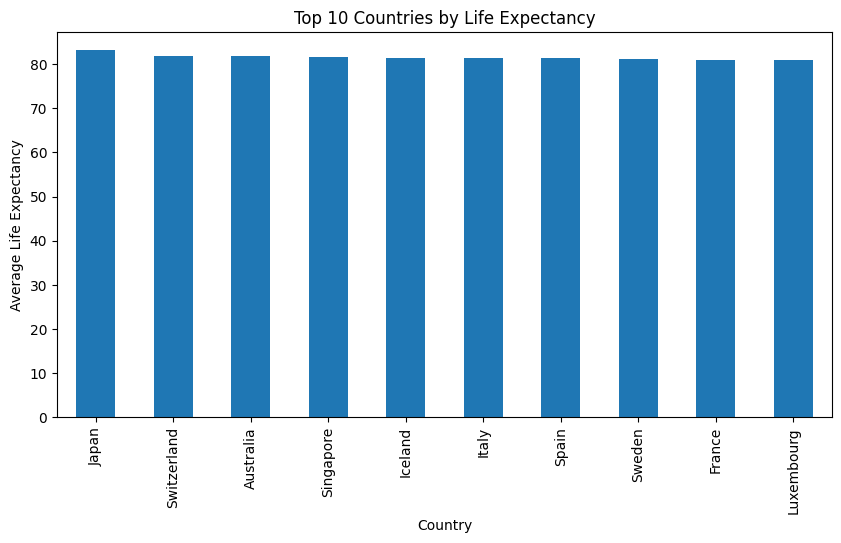

In [ ]:
top10 = (
    df_filtered.groupby('GEO_NAME_SHORT')['AMOUNT_N']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top10.plot(kind='bar')

plt.title('Top 10 Countries by Life Expectancy')
plt.xlabel('Country')
plt.ylabel('Average Life Expectancy')

plt.show()

**Insight**

The chart shows the countries with the highest life expectancy. These countries likely have strong healthcare systems and better living standards.

Question. 12

Which countries have the lowest life expectancy?

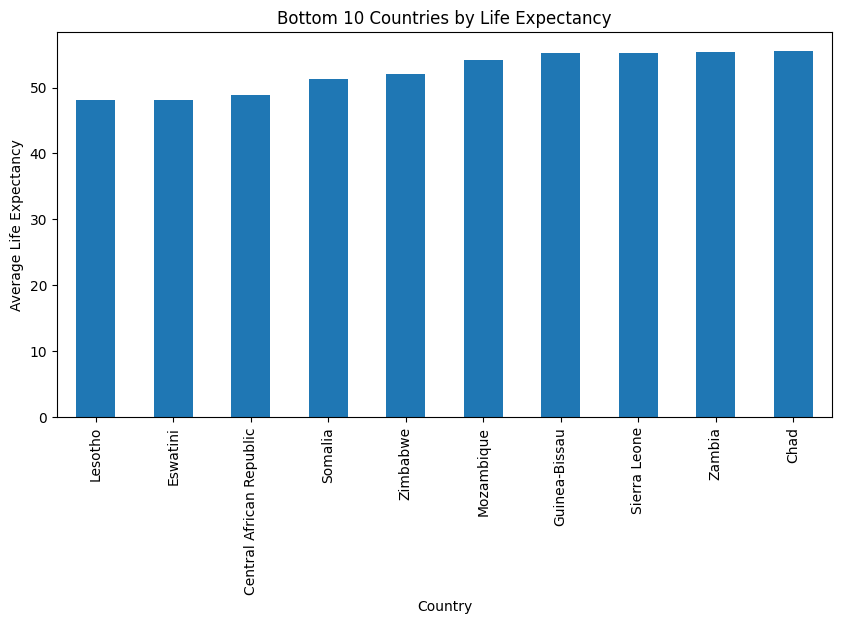

In [ ]:
bottom10 = (
    df_filtered.groupby('GEO_NAME_SHORT')['AMOUNT_N']
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(10,5))

bottom10.plot(kind='bar')

plt.title('Bottom 10 Countries by Life Expectancy')
plt.xlabel('Country')
plt.ylabel('Average Life Expectancy')

plt.show()

**Insight**

The chart identifies countries with the lowest life expectancy. These countries may face healthcare, economic, or social challenges.

# **3️⃣**. **MULTIVARIATE ANALYSIS**

Analysis of three or more variables simultaneously.

Purpose:

-Discover complex patterns

-Understand interactions between multiple variables

Queation. 13

How does life expectancy vary across genders over time?

<Axes: xlabel='DIM_TIME', ylabel='AMOUNT_N'>

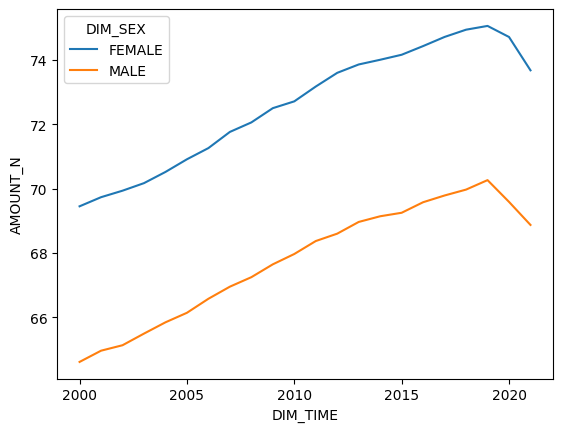

In [ ]:
gender_year = df_filtered.groupby(['DIM_TIME','DIM_SEX'])['AMOUNT_N'].mean().reset_index()

sns.lineplot(
    data=gender_year,
    x='DIM_TIME',
    y='AMOUNT_N',
    hue='DIM_SEX'
)

**Insight**

Life expectancy increases over time for all genders. Female life expectancy remains consistently higher.

Question. 14

How are life expectancy categories distributed across genders?

<Axes: xlabel='LIFE_EXPECTANCY_CATEGORY', ylabel='count'>

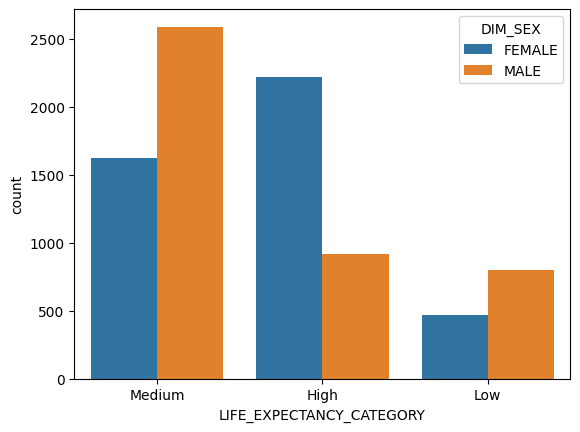

In [ ]:
sns.countplot(
    x='LIFE_EXPECTANCY_CATEGORY',
    hue='DIM_SEX',
    data=df_filtered
)

**Insight**

High life expectancy categories are more common among females. Gender influences life expectancy outcomes.

Question. 15

How is life expectancy distributed across genders and life expectancy categories?

In [ ]:
import plotly.express as px

fig = px.sunburst(
    df_filtered,
    path=['DIM_SEX', 'LIFE_EXPECTANCY_CATEGORY'],
    title='Life Expectancy Categories by Gender'
)

fig.show()

**Insight**

Shows the hierarchical distribution of life expectancy categories within each gender.Helps identify which life expectancy category is most common for each gender group.

Question. 16

Which countries contribute most to high life expectancy values?

In [ ]:
country_avg = df_filtered.groupby('GEO_NAME_SHORT')['AMOUNT_N'].mean().reset_index()

fig = px.treemap(
    country_avg,
    path=['GEO_NAME_SHORT'],
    values='AMOUNT_N',
    title='Average Life Expectancy by Country'
)

fig.show()

**Insight**

Each rectangle represents a country. Larger rectangles indicate countries with higher average life expectancy.

Question. 17

How has life expectancy changed over time by gender?

In [ ]:
gender_year = df_filtered.groupby(
    ['DIM_TIME','DIM_SEX']
)['AMOUNT_N'].mean().reset_index()

fig = px.line(
    gender_year,
    x='DIM_TIME',
    y='AMOUNT_N',
    color='DIM_SEX',
    markers=True,
    title='Life Expectancy Trend by Gender'
)

fig.show()

**Insight**

Shows life expectancy trends for Male, Female, and Both categories. Female life expectancy consistently remains higher across years.

Question. 18

What patterns exist between geographic code type and gender?

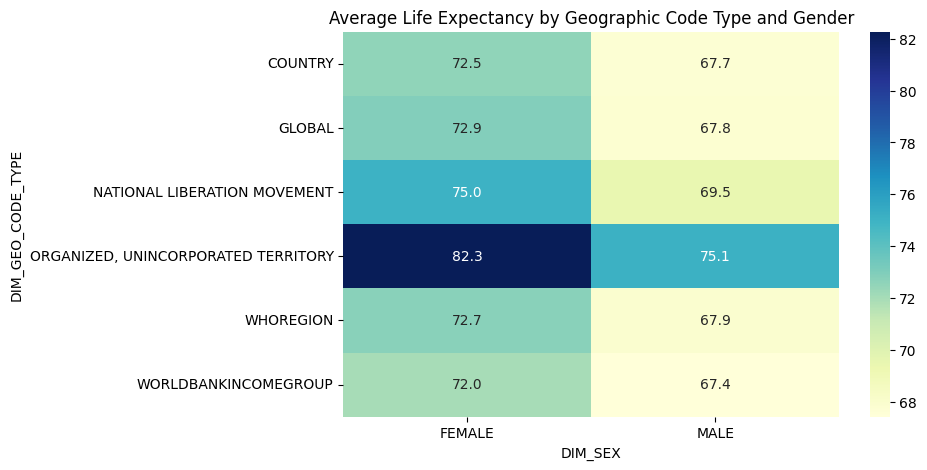

In [ ]:
pivot_geo_sex = pd.pivot_table(
    df_filtered,
    values='AMOUNT_N',
    index='DIM_GEO_CODE_TYPE',
    columns='DIM_SEX',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot_geo_sex,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu'
)

plt.title('Average Life Expectancy by Geographic Code Type and Gender')

plt.show()

**Insight**

Darker colors indicate higher average life expectancy.

**📋 Pivot Table Analysis**

Question. 19

How does average life expectancy vary across years and genders?

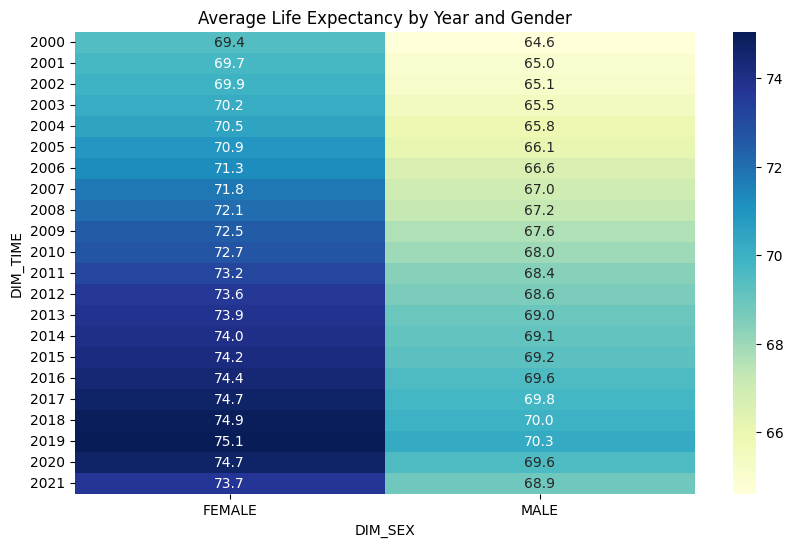

In [ ]:
pivot_heatmap = pd.pivot_table(
    df_filtered,
    values='AMOUNT_N',
    index='DIM_TIME',
    columns='DIM_SEX',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_heatmap,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu'
)

plt.title('Average Life Expectancy by Year and Gender')

plt.show()

**Insight**

Displays average life expectancy for each gender across years. Makes it easy to identify trends and compare gender differences over time.

Question. 20

Which year had the highest life expectancy?

In [ ]:
pivot_year_max = pd.pivot_table(
    df_filtered,
    values='AMOUNT_N',
    index='DIM_TIME',
    aggfunc='mean'
).sort_values(by='AMOUNT_N', ascending=False)

print(pivot_year_max.head())

           AMOUNT_N
DIM_TIME           
2019      72.658438
2018      72.452788
2017      72.235996
2020      72.161839
2016      72.008260


**Insight**

Lists years with the highest average life expectancy. Identifies periods of peak global health outcomes.

Question. 21

Which gender shows greater variation in life expectancy?

In [ ]:
pivot_std = pd.pivot_table(
    df_filtered,
    values='AMOUNT_N',
    index='DIM_SEX',
    aggfunc='std'
)

print(pivot_std)

         AMOUNT_N
DIM_SEX          
FEMALE   8.878431
MALE     8.286644


**Insight**

Shows standard deviation for each gender. Higher standard deviation indicates greater variation in life expectancy values.

Question. 22

What is the average life expectancy by country and gender?

In [ ]:
pivot_multi = pd.pivot_table(
    df_filtered,
    values='AMOUNT_N',
    index=['GEO_NAME_SHORT', 'DIM_SEX'],
    aggfunc='mean'
)

print(pivot_multi.head(20))

                              AMOUNT_N
GEO_NAME_SHORT      DIM_SEX           
Afghanistan         FEMALE   59.179078
                    MALE     57.732007
Africa              FEMALE   60.688745
                    MALE     57.643637
Albania             FEMALE   78.665428
                    MALE     74.036680
Algeria             FEMALE   75.683266
                    MALE     74.296670
Americas            FEMALE   78.578683
                    MALE     73.031260
Angola              FEMALE   59.607283
                    MALE     55.267059
Antigua and Barbuda FEMALE   77.511562
                    MALE     73.367989
Argentina           FEMALE   78.916868
                    MALE     72.307146
Armenia             FEMALE   76.953815
                    MALE     68.801402
Australia           FEMALE   83.818407
                    MALE     79.706202


**Insight**

Displays average life expectancy for each country-gender combination. Provides detailed country-level demographic analysis.

Question. 23

Which geographic code type shows the greatest variation in life expectancy?

In [ ]:
pivot_std_geo = pd.pivot_table(
    df_filtered,
    values='AMOUNT_N',
    index='DIM_GEO_CODE_TYPE',
    aggfunc='std'
)

print(pivot_std_geo)

                                     AMOUNT_N
DIM_GEO_CODE_TYPE                            
COUNTRY                              9.037789
GLOBAL                               3.294637
NATIONAL LIBERATION MOVEMENT         3.863907
ORGANIZED, UNINCORPORATED TERRITORY  3.867922
WHOREGION                            6.862875
WORLDBANKINCOMEGROUP                 7.954942


**Insight**

Higher standard deviation indicates greater variability.

# 💡 **Key Insights**

💡**1: Female Life Expectancy is Higher**

Observation

The average life expectancy of females is consistently higher than that of males.

Insight

This suggests that women generally have greater longevity across most countries.

💡**2: Global Life Expectancy Shows an Upward Trend**

Observation

The line chart of average life expectancy over time shows a gradual increase.

Insight

Improvements in healthcare, sanitation, nutrition, and living standards have contributed to longer lifespans.

💡**3: Significant Differences Exist Between Countries**

Observation

The Top 10 and Bottom 10 country analyses reveal large variations in life expectancy.

Insight

Socio-economic conditions, healthcare infrastructure, and public health policies strongly influence life expectancy.

💡**4: Most Countries Fall into Medium and High Categories**

Observation

The count plot of LIFE_EXPECTANCY_CATEGORY shows that most records belong to Medium and High groups.

Insight

Many countries have achieved considerable improvements in population health and longevity.

💡**5: Presence of Outliers Indicates Global Health Inequality**

Observation

The boxplot and IQR method identified several outliers.

Insight

These outliers represent countries with exceptionally low life expectancy and highlight disparities in global health outcomes.

# **📋 Summary**

This project analyzed global life expectancy data using Python. The dataset was cleaned by handling missing values, checking duplicates, standardizing text formats, and creating derived features. Data transformation and outlier detection were performed to improve data quality.

Exploratory Data Analysis (EDA) was conducted using univariate, bivariate, and multivariate techniques. Various visualizations helped identify trends, patterns, and relationships within the data.

The analysis revealed gender-based differences, country-level variations, and  positive life expectancy trends over time

# **✅ Conclusion**

The objective of this project was to analyze global life expectancy data and identify factors influencing lifespan across different populations.

The results showed that:

-Female life expectancy is generally higher than male life expectancy.

-Global life expectancy has improved over time.

-Significant differences exist among countries.

-Most observations belong to medium and high life expectancy categories.



Through data cleaning, preprocessing, exploratory analysis, and visualization, this project successfully identified important trends and disparities in global life expectancy, demonstrating the value of data analytics in understanding public health outcomes.